# Normalize Total Gradient (NTG) - From the Scratch (v1)

### Importamos las librerías necesarias para calcular el NTG

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

### Cargamos las imágenes

In [2]:
ti = 1 # Definimos el total de imagenes a trabajar

## -- Inicialización de listas para almacenar las imagenes -- ##

img_BGR = []                # Lista de imagenes BGR (formato base)
img_IR = []                 # Lista de imagenes NIR (espectro IR)
img_RGB = []                # Lista de imagenes RGB (conversión para visualización de color apropiada)
img_RGBgray = []            # Lista de imagenes RGB en grayscale (usado para aplicar operaciones)
img_IR_translation = []     # Lista de imagenes NIR con aberraciones (traslación)

## -- Carga de imagenes del dataset y operaciones sobre ellas (aberraciones,conversiones,etc.) -- ## {n:03d}
for n in range(1):
    bgr = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Sat_images/Photos_2018/GC_019.png')
    ir = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Additional_data/Infrared_images/Infrared_2018/GC_019_Infrarred.png',cv2.IMREAD_GRAYSCALE)

    # Verificación de carga correcta de imagenes
    if bgr is None or ir is None:
        print(f'Error al cargar la imagen {n}')
        continue

    ## -- Conversiones de formato -- ##
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)          # Conversión de BGR a RGB
    rgb_gray = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)    # Conversión de RGB a Grayscale

    
    ## -- ABERRACIÓN - imagen IR desplazada (en x, y o ambas) -- ##
    h_ir, w_ir = ir.shape[:2]                                    # Obtenemos las dimensiones de la imagen

    tras_x = 200                                                 # Pixeles de desplazamiento en x (+ derecha, - izquierda)
    tras_y = 200                                                 # Pixeles de desplazamiento en y (+ abajo, - arriba)
    m_translation = np.float32([[1,0,tras_x],[0,1,tras_y]])      # Matriz de traslación 

    translation_imgIR = cv2.warpAffine(ir,m_translation,(w_ir,h_ir)) # Generamos la imagen con traslación

    # -- Guardar la imagenes en sus respectivas listas -- ##
    img_BGR.append(bgr)                            # Agregar las imagenes BGR a la lista
    img_RGB.append(rgb)                            # Agregar las imagenes RGB a la lista
    img_IR.append(ir)                              # Agregar las imagenes NIR a la lista
    img_RGBgray.append(rgb_gray)                   # Agregar las imagenes RGB en grayscale a la lista
    img_IR_translation.append(translation_imgIR)   # Agregar las imagenes NIR con traslación a la lista

(982, 1964)


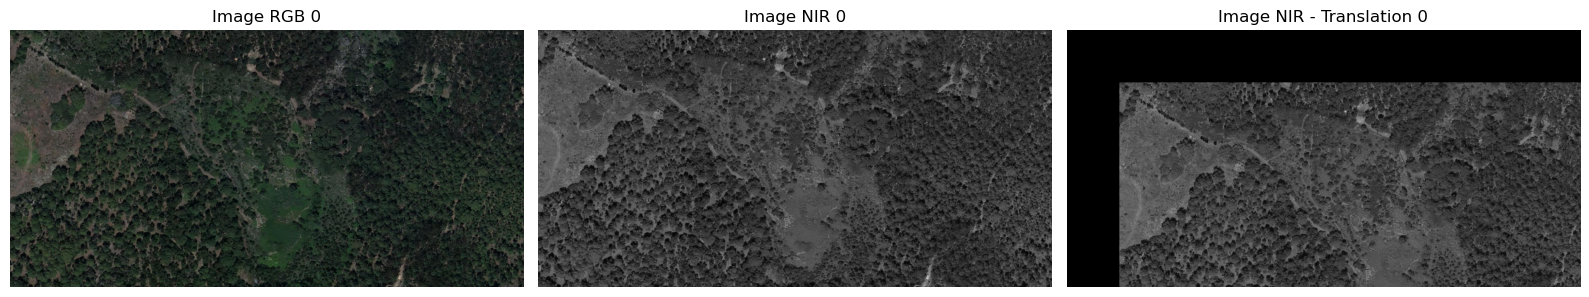

In [3]:
for n in range(len(img_RGB)):
    plt.figure(figsize=(16,14))
    
    plt.subplot(1,3,1)
    plt.title(f"Image RGB {n}")
    plt.imshow(img_RGB[n])
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title(f"Image NIR {n}")
    plt.imshow(img_IR[n],cmap='gray')
    plt.axis('off')
    print(img_RGBgray[n].shape)

    plt.subplot(1,3,3)
    plt.title(f"Image NIR - Translation {n}")
    plt.imshow(img_IR_translation[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## NTG - Versión I [versión base aproximada al paper de Cheng]

### Step I - Normalización

In [4]:
## === FUNCIÓN DE NORMALIZACIÓN PARA NTG === ##
def normalize_image(img):
    
    img = img.astype(np.float32)    # Conversión del tipo de dato a float de 32 bits

    min_val = np.min(img)           # Valores mínimos de la imagen normalizada
    max_val = np.max(img)           # Valores máximos de la imagen normalizada

    if max_val - min_val < 1e-8:    # Control para evitar divisiones entre 0 y con ello errores
        return np.zeros_like(img)

    norm_img = (img - min_val)/(max_val - min_val)  # Normalizamos la intensidad de la imagen
    
    return norm_img

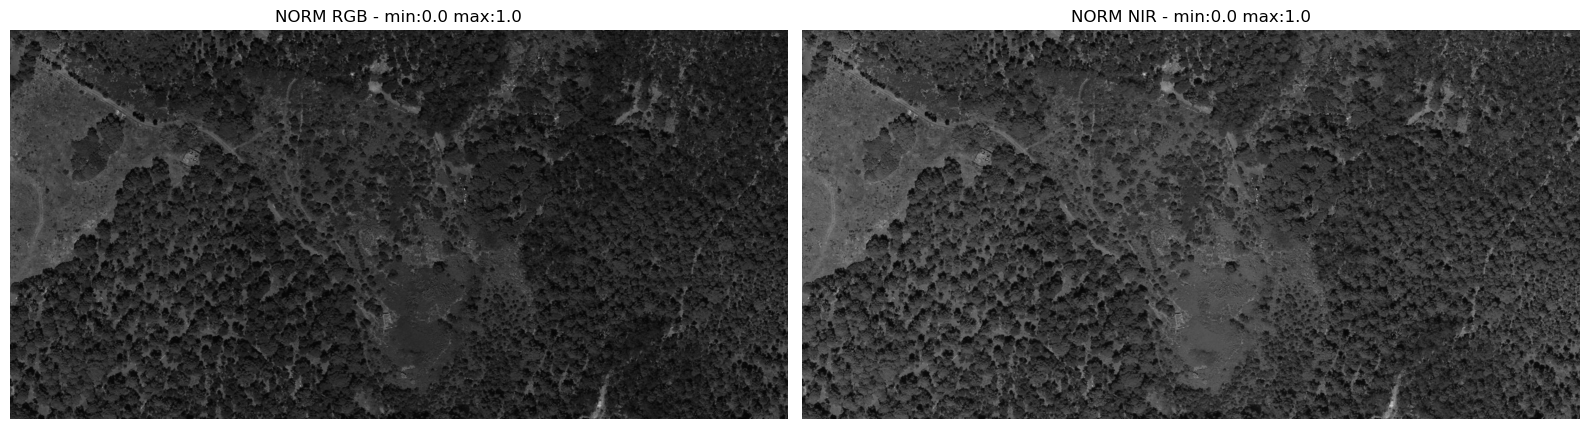

In [5]:
## -- Listas para guardar las imagenes normalizadas -- ##

normRGB_list = []     # Lista para imágenes RGB normalizadas
normNIR_list = []     # Lista para imágener NIR normalizadas 


for n in range(len(img_RGB)):

    ## --- Normalización --- ##
    
    norm_RGB = normalize_image(img_RGBgray[n])    # Normalizamos la imagen RGB
    norm_NIR = normalize_image(img_IR[n])    # Normalizamos la imagen NIR

    ## --- Guardamos las imagenes normalizadas --- ##
    
    normRGB_list.append(norm_RGB)   # Imagen RGB normalizada
    normNIR_list.append(norm_NIR)   # Imagen NIR normalizada

    ## --- VISUALIZACIÓN --- ##
    plt.figure(figsize=(16,14))

    plt.subplot(1,2,1)
    plt.title(f"NORM RGB - min:{normRGB_list[n].min()} max:{normRGB_list[n].max()}")
    plt.imshow(normRGB_list[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"NORM NIR - min:{normNIR_list[n].min()} max:{normNIR_list[n].max()}")
    plt.imshow(normNIR_list[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### STEP II - Cálculo de gradientes

In [6]:
## === FUNCIÓN PARA CALCULAR EL GRADIENTE === ##
def compute_gradients(img):

    ## --- Gradiente X --- ##
    gx = cv2.Sobel(img,cv2.CV_32F,1,0,ksize=3)

    ## --- Gradiente Y --- ##
    gy = cv2.Sobel(img,cv2.CV_32F,0,1,ksize=3)

    return gx, gy

In [7]:
## --- Listas para guardar el gradiente del RGB --- ##

rgb_GX_list = []    # Lista para gradientes RGB X
rgb_GY_list = []    # Lista para gradientes RGB Y

for n in range(len(img_RGB)):
   
    rgb_gx, rgb_gy = compute_gradients(img_RGBgray[n])  # Obtención del Gradiente de la imagen RGB

    ## --- Guardamos las gradientes --- ##
    
    rgb_GX_list.append(rgb_gx)   # Gradiente GX
    rgb_GY_list.append(rgb_gy)   # Gradiente GY

### STEP III - Cálculo de la transformación afín, warp y overlap

#### Matriz Afín

In [8]:
## === FUNCIÓN PARA CÁLCULAR LA MATRIZ AFÍN === ##
def affine_matrix(p):

    ## -- Parámetros para la M. Afín -- ##
    
    p1, p2, p3, p4, p5, p6 = p  # Afinidad dada por: escala X, escala Y, shear, rotación y traslación

    ## -- Generar la Matriz Afín -- ##
    M = np.array([
        [p1, p2, p3],
        [p4, p5, p6]
    ], dtype=np.float32)

    return M

#### Warp para NIR

In [9]:
## === FUNCIÓN PARA REALIZAR EL WARP PARA LA IMAGEN EN NIR === ###
def warp_image(img,p,output_size):

    ## --- Cálcular la matriz afín --- ##
    M = affine_matrix(p)

    ## --- Tamaño de la salida --- ##
    W, H = output_size

    ## --- Ejecutamos el WarpAffine con los parámetros dados --- ##
    warped = cv2.warpAffine(
        img,
        M,
        (W, H),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return warped

#### Overlaping

In [10]:
## === FUNCIÓN PARA GENERAR EL TRASLAPE ENTRE NIR Y RGB === ##
def warp_mask(shape,p):

    ## --- Obetenemos la matriz afín --- ##
    M = affine_matrix(p)
    
    ## --- Obtenemos las dimensiones de la imagen --- ##
    H, W = shape

    ## --- Generamos la máscara general donde se ajustaran los datos --- ##
    mask = np.ones((H,W), dtype=np.uint8)

    ## --- Obtenemos la matriz afín --- ##
    warped_mask = cv2.warpAffine(
        mask,
        M,
        (W,H),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return warped_mask.astype(bool)

### STEP IV - Normalized Total Gradient [NTG]

In [11]:
## === FUNCIÓN PARA CALCULAR EL NUCLEO DEL MÉTODO NTG === ##
def compute_ntg(img_reference,reference_gx,reference_gy,img_floating,identity_params):

    ## --- Extracción de las dimensiones de la imagen de referencia (RGB) --- ##
    H, W = img_reference.shape[:2]

    ## --- Deformación de la imagen NIR para ajustarla a la RGB --- ##
    warped = warp_image(img_floating,identity_params,(W,H))

    ## --- Máscara de traslape --- ##
    mask = warp_mask(img_floating.shape,
                     identity_params
                    )

    overlap_pixels = np.sum(mask)

    ## --- Evitar soluciones invalidas (No se ajustan) --- ##
    if overlap_pixels < 100:
        return 1.0

    ## --- Gradientes de la imagen warped NIR --- ##
    warped_gx, warped_gy = compute_gradients(warped)

    ## --- Diferencia entre los gradientes del RGB y NIR warped --- ##
    diff_gx = warped_gx - reference_gx     # Gradiente en X
    diff_gy = warped_gy - reference_gy     # Gradiente en Y

    ## --- Cálculo del Numerador NTG --- ##
    numerator = (np.sum(np.abs(diff_gx[mask])) + np.sum(np.abs(diff_gy[mask])))

    ## --- Cálculo del Denominador NTG --- ##
    denominator = (np.sum(np.abs(warped_gx[mask])) + np.sum(np.abs(warped_gy[mask])) +
                   np.sum(np.abs(reference_gx[mask])) + np.sum(np.abs(reference_gy[mask])))
    
    if denominator < 1e-8:                # Caso para evitar la división entre 0
        return 1.0

    ## --- Cálculo final del NTG del modelo afín --- ##
    ntg = numerator / denominator

    return float(ntg)

In [12]:
# ============================================================
# 6. TEST NTG WITH TRANSLATION
# ============================================================

p_identity = np.array([
    1.0, 0.0, 0.0,
    0.0, 1.0, 0.0
])

p_shift = np.array([
    1.0, 0.0, 30.0,
    0.0, 1.0, 20.0
])

ntg_identity = compute_ntg(
    img_RGBgray[0],
    rgb_GX_list[0],
    rgb_GY_list[0],
    img_IR[0],
    p_identity
)

ntg_shift = compute_ntg(
    img_RGBgray[0],
    rgb_GX_list[0],
    rgb_GY_list[0],
    img_IR[0],
    p_shift
)

print("NTG identity:", ntg_identity)
print("NTG shifted :", ntg_shift)

NTG identity: 0.18640851974487305
NTG shifted : 0.7390702962875366


In [21]:
# ============================================================
# 7. NTG LANDSCAPE FOR TRANSLATION
# ============================================================

tx_values = np.arange(-50, 51, 1)
ty_values = np.arange(-50, 51, 1)

ntg_map = np.zeros(
    (len(ty_values), len(tx_values))
)

for i, ty in enumerate(ty_values):

    for j, tx in enumerate(tx_values):

        p = np.array([
            1.0, 0.0, tx,
            0.0, 1.0, ty
        ])

        ntg_map[i, j] = compute_ntg(
            img_RGBgray[0],
            rgb_GX_list[0],
            rgb_GY_list[0],
            img_IR[0],
            p
        )

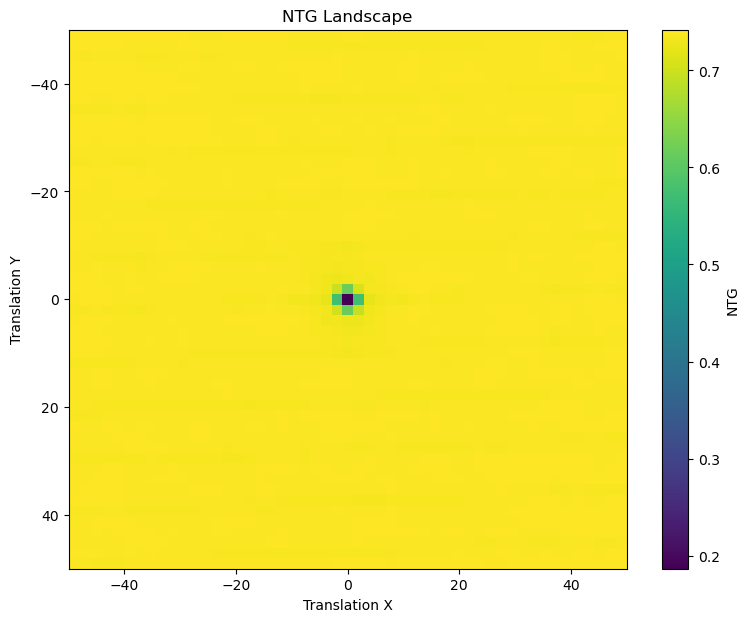

In [14]:
plt.figure(figsize=(9, 7))

plt.imshow(
    ntg_map,
    extent=[
        tx_values[0],
        tx_values[-1],
        ty_values[-1],
        ty_values[0]
    ],
    aspect="auto"
)

plt.colorbar(label="NTG")

plt.xlabel("Translation X")
plt.ylabel("Translation Y")
plt.title("NTG Landscape")

plt.show()

In [15]:
# ============================================================
# 8. DIFFERENTIAL EVOLUTION
# ============================================================

def ntg_objective(p):
    return compute_ntg(img_RGBgray[0],rgb_GX_list[0],rgb_GY_list[0],img_IR[0],p_identity)

In [16]:
bounds = [
    (0.95, 1.05),   # p1
    (-0.05, 0.05),  # p2
    (-10, 10),      # p3
    (-0.05, 0.05),  # p4
    (0.95, 1.05),   # p5
    (-10, 10)       # p6
]

In [17]:
result = differential_evolution(
    ntg_objective,
    bounds=bounds,
    popsize=30,
    maxiter=200,
    polish=False,
    workers=1,
    updating="immediate",
    disp=True,
    seed=42
)

differential_evolution step 1: f(x)= 0.18640851974487305


In [18]:
print("\nOptimization finished")
print("----------------------")

print("Best NTG:")
print(result.fun)

print("\nBest parameters:")
print(result.x)

print("\nAffine matrix:")
print(
    affine_matrix(result.x)
)


Optimization finished
----------------------
Best NTG:
0.18640851974487305

Best parameters:
[ 1.02455108e+00  3.53997632e-02 -4.27134589e+00 -3.59105757e-03
  9.70293178e-01 -3.88259240e+00]

Affine matrix:
[[ 1.0245510e+00  3.5399765e-02 -4.2713461e+00]
 [-3.5910576e-03  9.7029316e-01 -3.8825924e+00]]


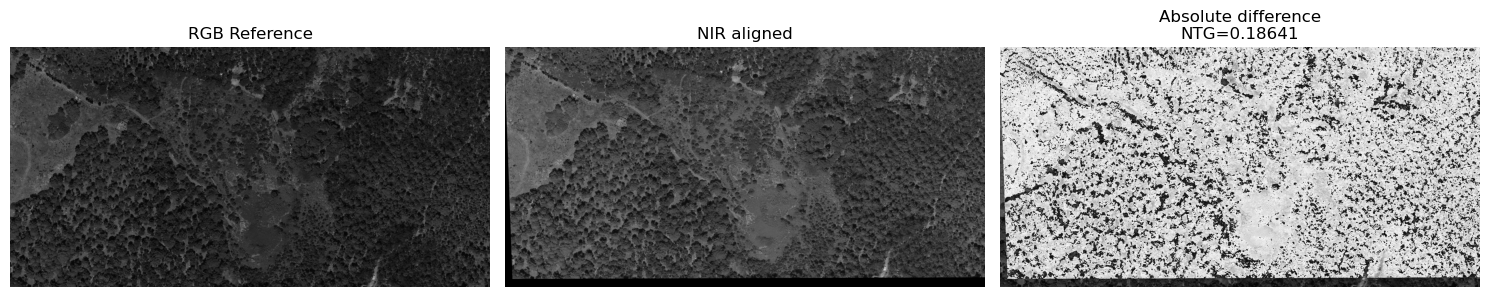

In [19]:
# ============================================================
# 9. VISUALIZATION
# ============================================================

best_p = result.x
H, W = img_IR[0].shape[:2]

nir_aligned = warp_image(
    img_IR[0],
    best_p,
    (W, H)
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_RGBgray[0], cmap="gray")
plt.title("RGB Reference")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nir_aligned, cmap="gray")
plt.title("NIR aligned")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    np.abs(img_RGBgray[0] - nir_aligned),
    cmap="gray"
)

plt.title(
    f"Absolute difference\nNTG={result.fun:.5f}"
)

plt.axis("off")

plt.tight_layout()
plt.show()